# ADIM 1 — Tanı & Temizlik + EDA + Leakage denetimi

5 churn veri seti **bağımsız** işlenir; setler asla birleştirilmez, çıktılar
set bazında ayrıdır. Bu adımda **encoding yapılmaz** (kategorikler ham bırakılır)
ve **modellemeye geçilmez**. Ağır mantık `src/` fonksiyonlarındadır; bu script
yalnızca onları sırayla çağırır (Shift+Enter ile hücre hücre çalıştırılabilir).

In [1]:
# Ortak kurulum: importlar + seed(42) + ortak figür stili.
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml bulunamadı — depo kökünden çalıştırın")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

from src import clean as clean_mod
from src import config as cfg
from src import eda as eda_mod
from src import leakage as leak_mod
from src import load as load_mod
from src import plotstyle as ps
from src import strings_tr as S

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

CIKTI = []  # konsol özeti; sonda outputs/logs/ altına yazılır


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))

## 1. Ön kontrol ve profil
Dosyalar var mı, gerçek profil (satır/sütun/churn) referans değerlerle uyuyor mu?

In [2]:
yaz(S.MSG["bolum"].format(ad="ÖN KONTROL & PROFİL"))
_eksik = [d["file"] for d in cfg.DATASETS.values() if not (cfg.RAW / d["file"]).exists()]
if not (cfg.HOLDOUT / cfg.HOLDOUT_DOSYA).exists():
    _eksik.append(cfg.HOLDOUT_DOSYA)
assert not _eksik, S.MSG["on_kontrol_eksik"].format(dosya=", ".join(_eksik))

etiketli = load_mod.yukle_etiketli()
holdout = load_mod.yukle_holdout()

for key, d in cfg.DATASETS.items():
    info = etiketli[key]
    churn = 100 * info["df"]["churn"].mean()
    r = cfg.REFERANS[key]
    assert info["raw_shape"][0] == r[0], f"{key}: satır {info['raw_shape'][0]} != ref {r[0]}"
    yaz(S.MSG["profil_satiri"].format(
        set=key, satir=info["raw_shape"][0], sutun=info["raw_shape"][1],
        churn=churn, ref=f"{r[2]}%", hedef=d["target"]))
    if info["dropped"]:
        yaz("    " + S.MSG["id_dusuruldu"].format(set=key, kolonlar=info["dropped"]))

# etiketsiz holdout doğrulaması
assert holdout["df"]["churn"].isna().all(), "cell2cell_test etiketli görünüyor"
yaz(f"{'cell2cell_test':11s} {holdout['raw_shape'][0]:>6d}x{holdout['raw_shape'][1]:<3d}  ETİKETSİZ holdout")
yaz(S.MSG["on_kontrol_ok"].format(n=len(cfg.DATASETS)))

===== ÖN KONTROL & PROFİL =====
telco         7043x21   churn= 26.5%  (ref 26.5%)  hedef='Churn'
    telco: kimlik kolonu düşürüldü -> ['customerID']
cell2cell    51047x58   churn= 28.8%  (ref 28.8%)  hedef='Churn'
    cell2cell: kimlik kolonu düşürüldü -> ['CustomerID']
ecommerce     3941x11   churn= 17.1%  (ref 17.1%)  hedef='Churn'
iranian       3150x14   churn= 15.7%  (ref 15.7%)  hedef='Churn'
bank         10000x14   churn= 20.4%  (ref 20.4%)  hedef='Exited'
    bank: kimlik kolonu düşürüldü -> ['RowNumber', 'CustomerId', 'Surname']
cell2cell_test  20000x58   ETİKETSİZ holdout
Ön kontrol: 5 veri seti + 1 etiketsiz holdout bulundu, referans profillerle uyumlu.


## 2. Temizlik
Set bazında yalnızca güvenli işlemler (eksik doldurma + tip düzeltme). Çıktı:
`data/processed/<set>_clean.csv`. cell2cell holdout, train istatistikleriyle doldurulur.

In [3]:
yaz(S.MSG["bolum"].format(ad="TEMİZLİK"))
processed, temizlik_log = clean_mod.temizle_hepsi(etiketli, holdout)
for s, kolon, islem, detay in temizlik_log:
    yaz(S.MSG["temizlik_satiri"].format(set=s, kolon=kolon, islem=f"{islem} | {detay}"))

# temizlik_log -> CSV (Türkçe başlıklar)
clean_df = pd.DataFrame(temizlik_log, columns=[
    S.KOLON["veri_seti"], S.KOLON["kolon"], S.KOLON["islem"], S.KOLON["detay"]])
clean_df.to_csv(cfg.TABLES / "cleaning_log.csv", index=False)
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "cleaning_log.csv"))

===== TEMİZLİK =====


telco       TotalCharges                 metin -> sayısal + eksik doldurma | 11 boş; tenure=0 -> 0 (11 satır); kalan 0 -> medyan (1394.55)
cell2cell   MonthlyRevenue               eksik -> medyan | 156 hücre dolduruldu (48.46)
cell2cell   MonthlyMinutes               eksik -> medyan | 156 hücre dolduruldu (366.00)
cell2cell   TotalRecurringCharge         eksik -> medyan | 156 hücre dolduruldu (45.00)
cell2cell   DirectorAssistedCalls        eksik -> medyan | 156 hücre dolduruldu (0.25)
cell2cell   OverageMinutes               eksik -> medyan | 156 hücre dolduruldu (3.00)
cell2cell   RoamingCalls                 eksik -> medyan | 156 hücre dolduruldu (0.00)
cell2cell   PercChangeMinutes            eksik -> medyan | 367 hücre dolduruldu (-5.00)
cell2cell   PercChangeRevenues           eksik -> medyan | 367 hücre dolduruldu (-0.30)
cell2cell   ServiceArea                  eksik -> mod | 24 hücre dolduruldu (NYCBRO917)
cell2cell   Handsets                     eksik -> medyan | 1 hücre dold

## 3. Leakage (sızıntı) denetimi
Her etiketli sette her feature için tek-değişkenli churn AUC; ≥ 0.90 ŞÜPHELİ.
**Sadece rapor** — kolon düşürülmez, karar kullanıcıya bırakılır.

In [4]:
yaz(S.MSG["bolum"].format(ad="LEAKAGE DENETİMİ"))
leak_df = leak_mod.denetle_hepsi(processed)
supheli = leak_df[leak_df[S.KOLON["bayrak"]] == S.BAYRAK_SUPHELI]
if len(supheli):
    for _, r in supheli.iterrows():
        yaz(S.MSG["leakage_supheli"].format(
            set=r[S.KOLON["veri_seti"]], ozellik=r[S.KOLON["ozellik"]],
            auc=r[S.KOLON["tekil_auc"]], aksiyon=r[S.KOLON["aksiyon"]]))
else:
    yaz("Şüpheli (AUC ≥ 0.90) feature bulunamadı.")
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "leakage_audit.csv"))

===== LEAKAGE DENETİMİ =====


Şüpheli (AUC ≥ 0.90) feature bulunamadı.
Kaydedildi: /Users/emrahfidan/Desktop/churn-xai-profit/outputs/tables/leakage_audit.csv


## 4. EDA figürleri ve genel bakış
Her etiketli set için `outputs/figures/<set>/` altına 5 figür + genel bakış tablosu.

===== EDA FİGÜRLERİ =====


telco: 5 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/telco


cell2cell: 5 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/cell2cell
    (yüksek kardinalite, kategorik figürde atlandı: ['ServiceArea', 'HandsetPrice'])


ecommerce: 5 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/ecommerce


iranian: 5 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/iranian


/Users/emrahfidan/Desktop/churn-xai-profit/src/eda.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 4))


bank: 5 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/bank
Kaydedildi: /Users/emrahfidan/Desktop/churn-xai-profit/outputs/tables/dataset_overview.csv
     Veri Seti    Sektör  Satır  Sütun  Churn %  Eksik (öncesi)  Eksik (sonrası)                                                          Not
         telco   telecom   7043     21     26.5               0                0                                                             
     cell2cell   telecom  51047     58     28.8            3515                0                                                             
     ecommerce ecommerce   3941     11     17.1             576                0                                                             
       iranian   telecom   3150     14     15.7               0                0                                                             
          bank   banking  10000     14     20.4               0                0                                      

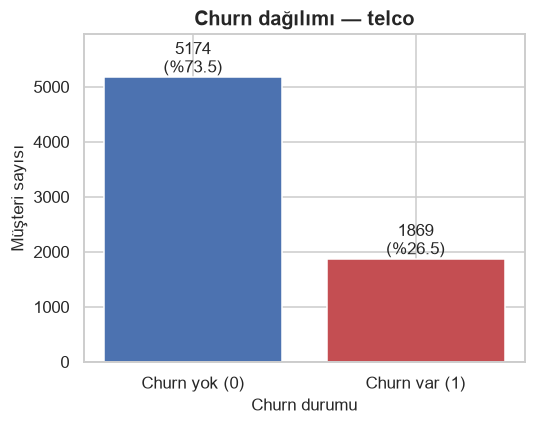

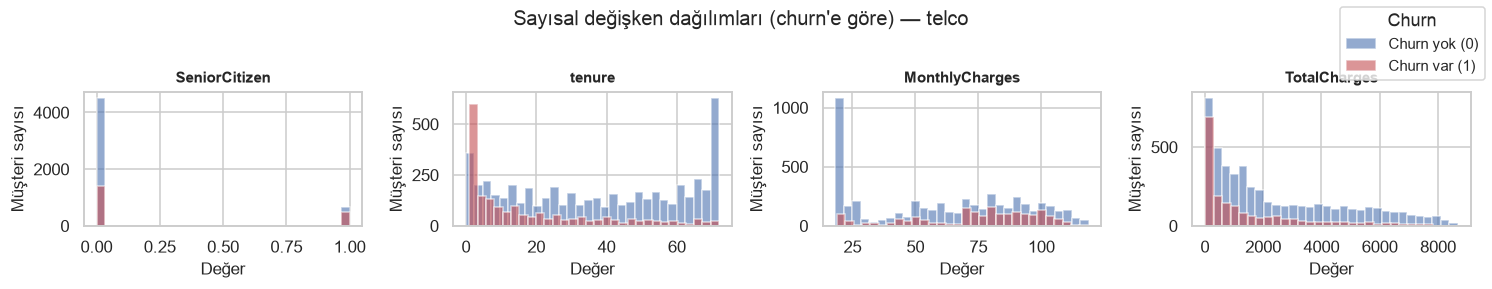

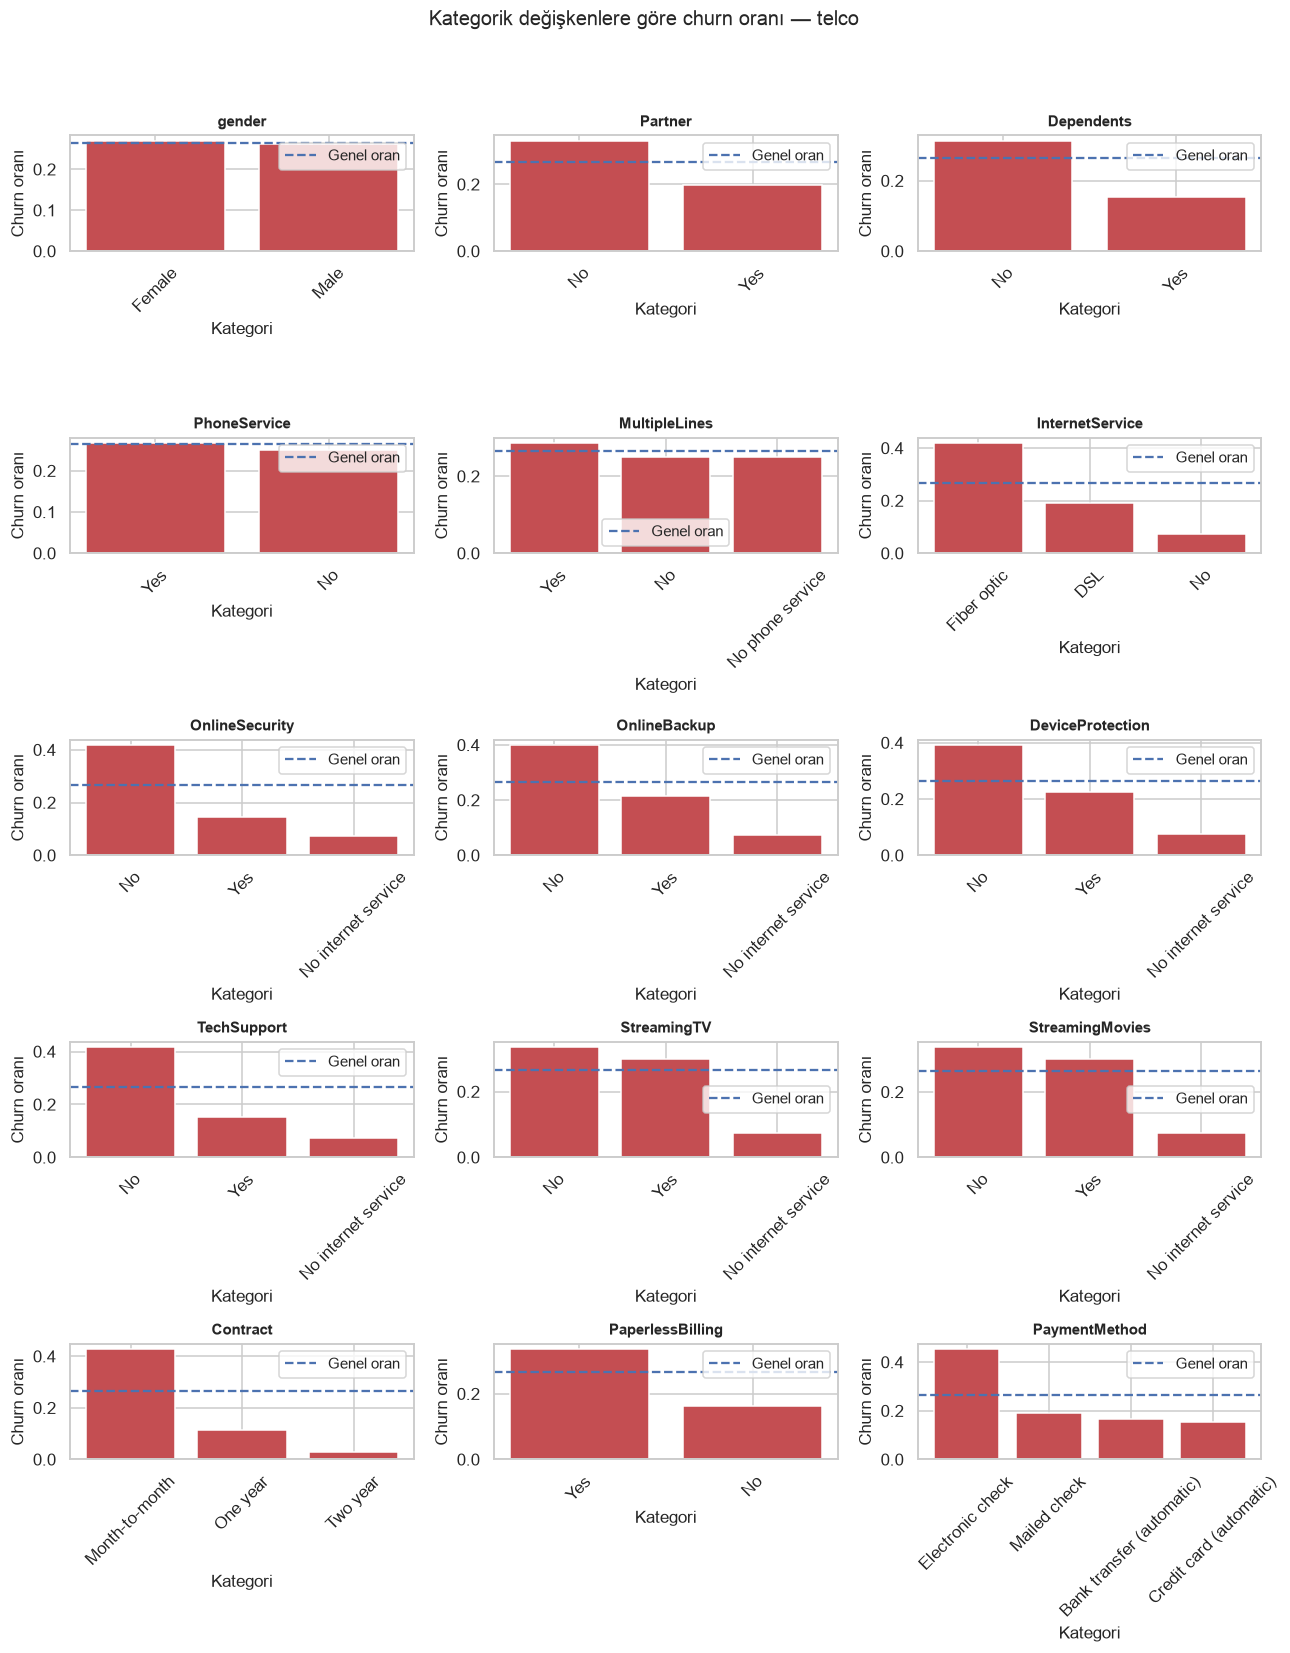

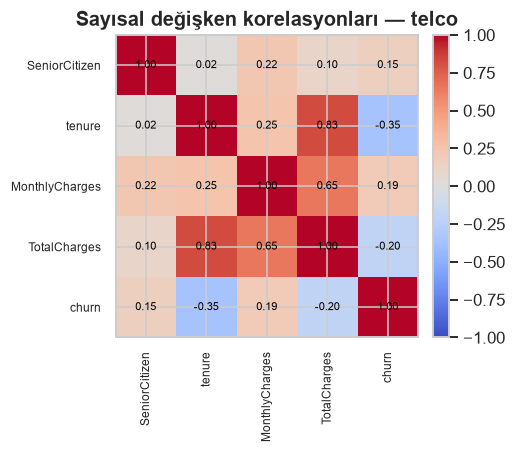

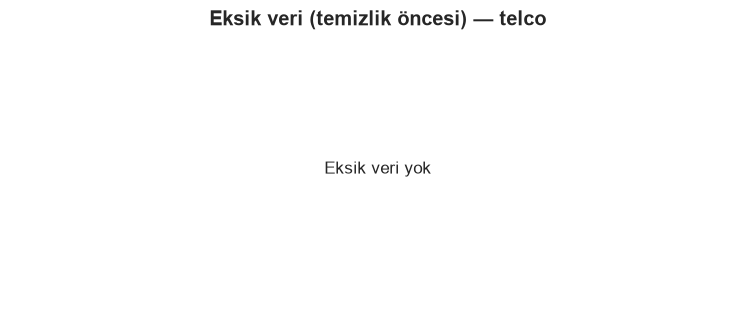

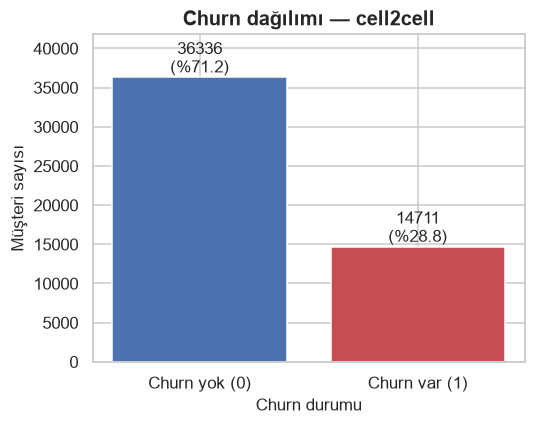

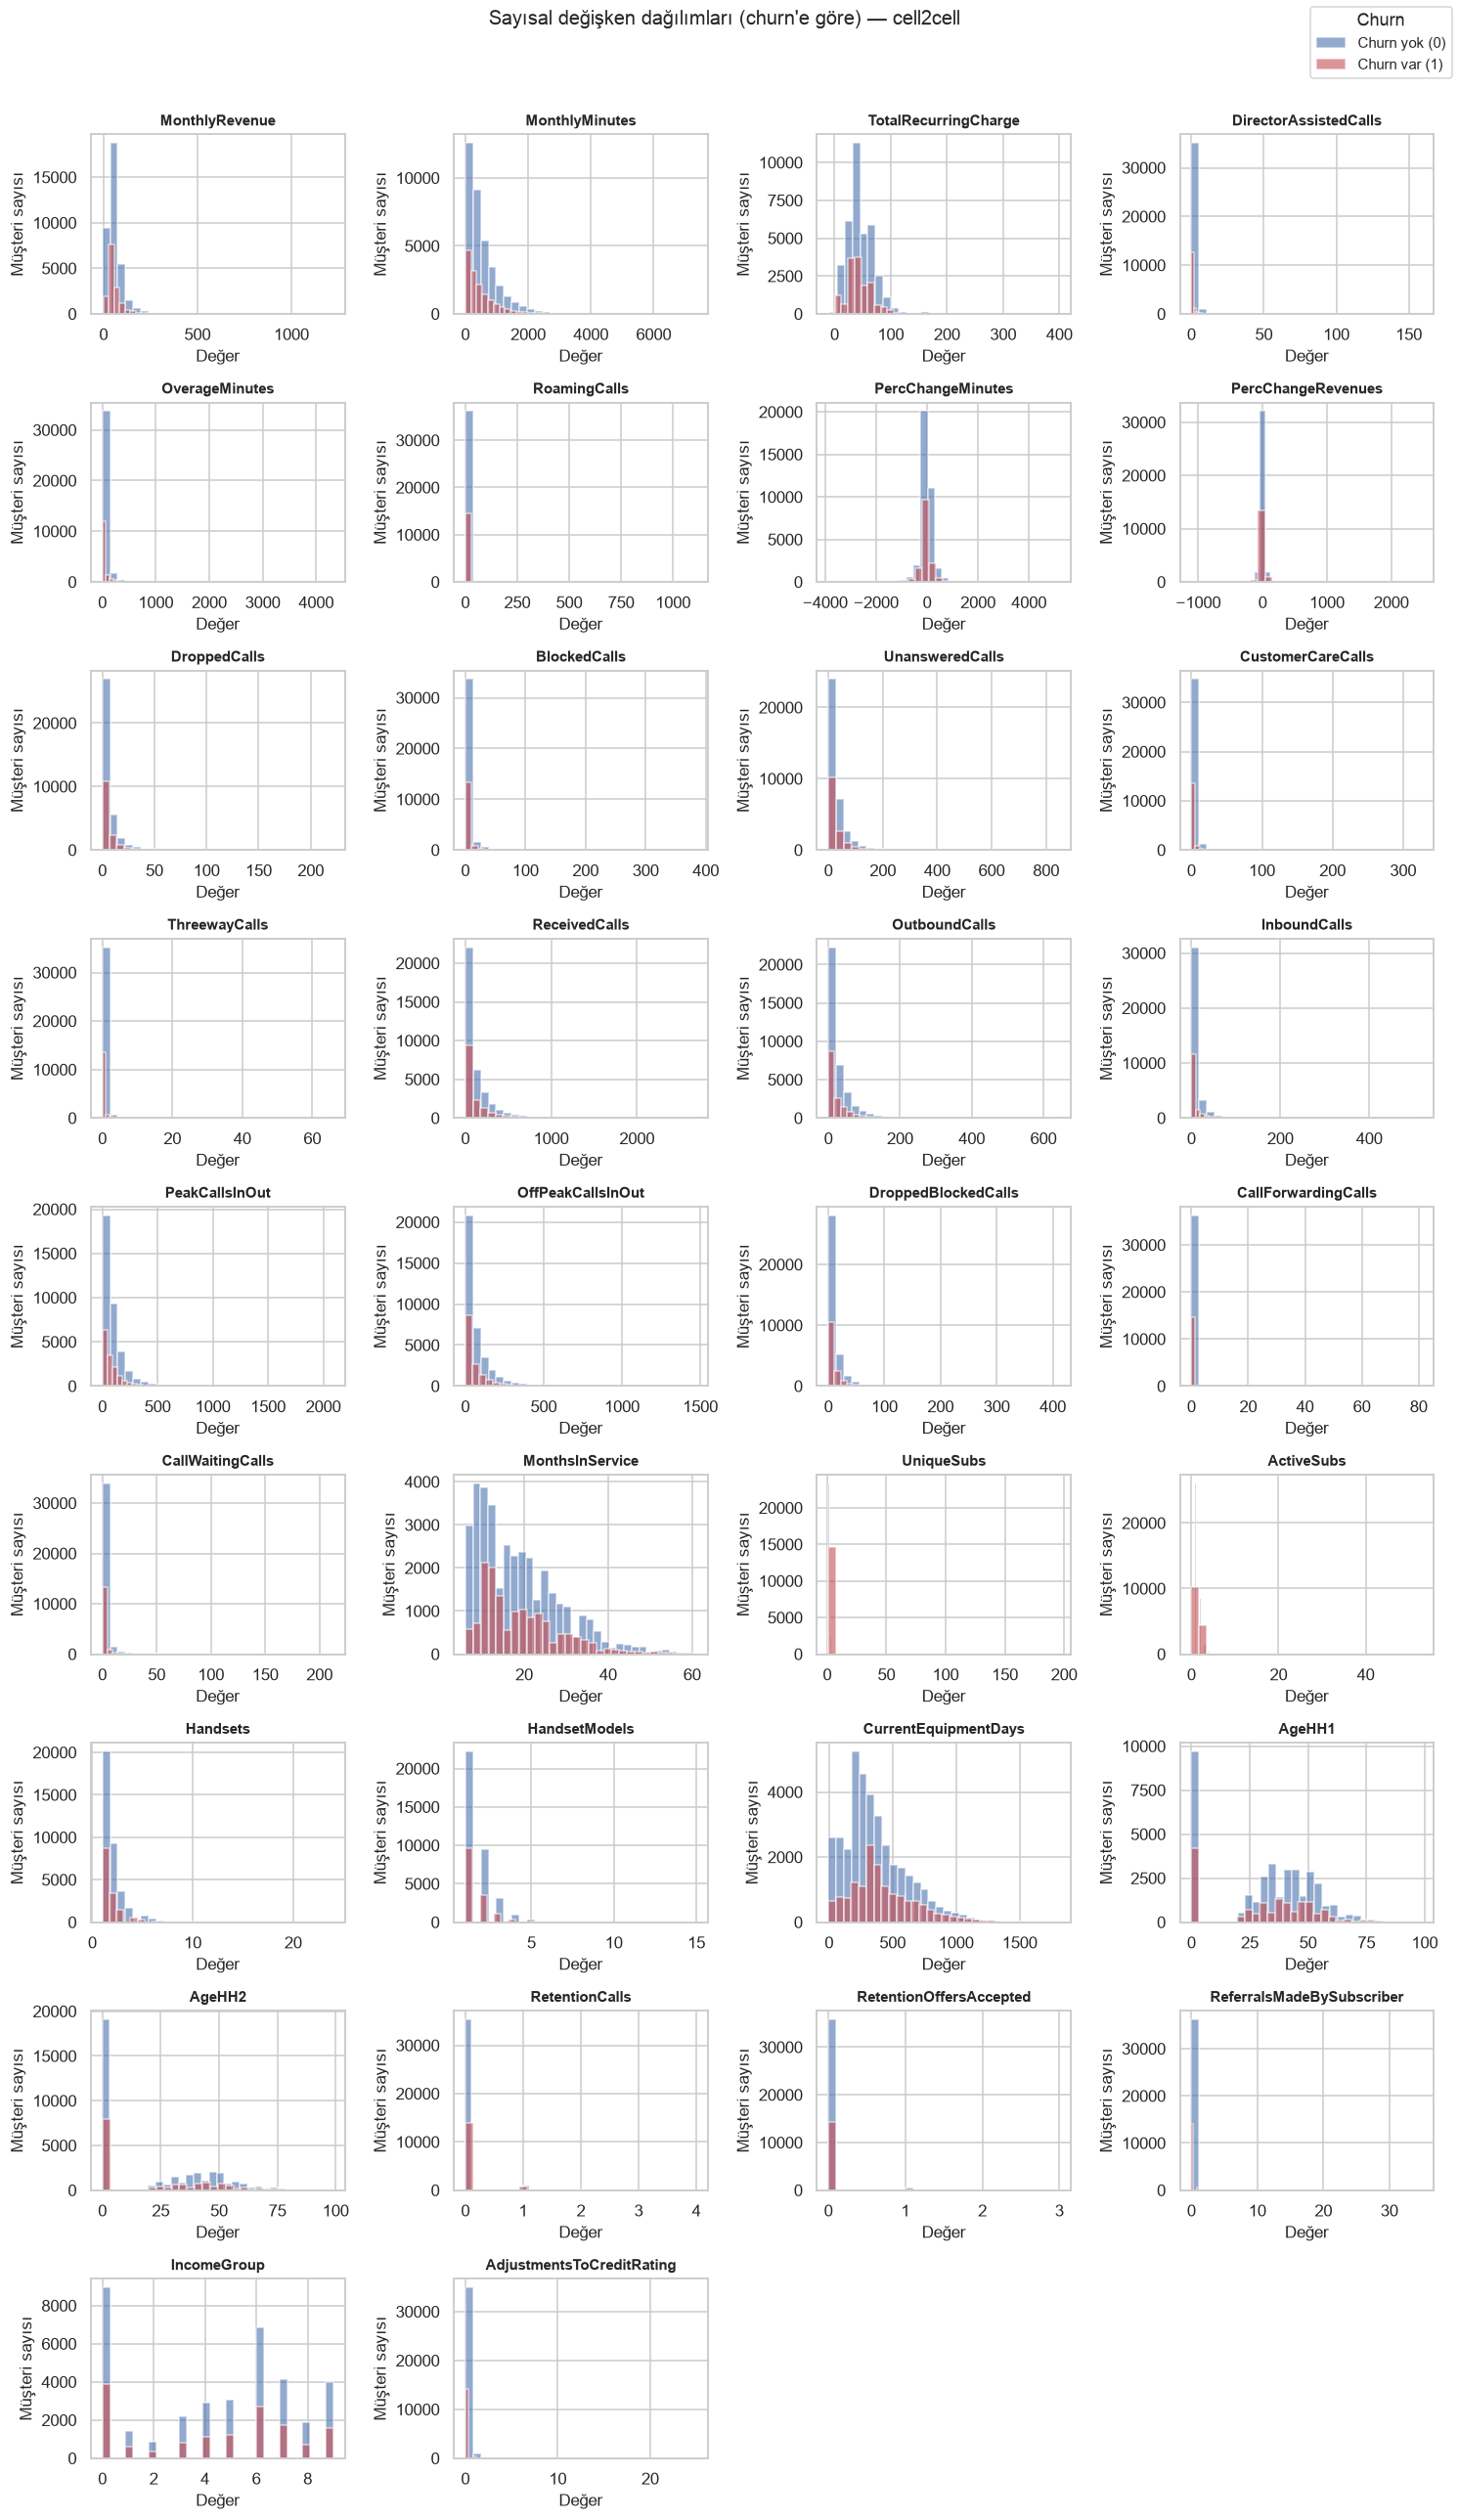

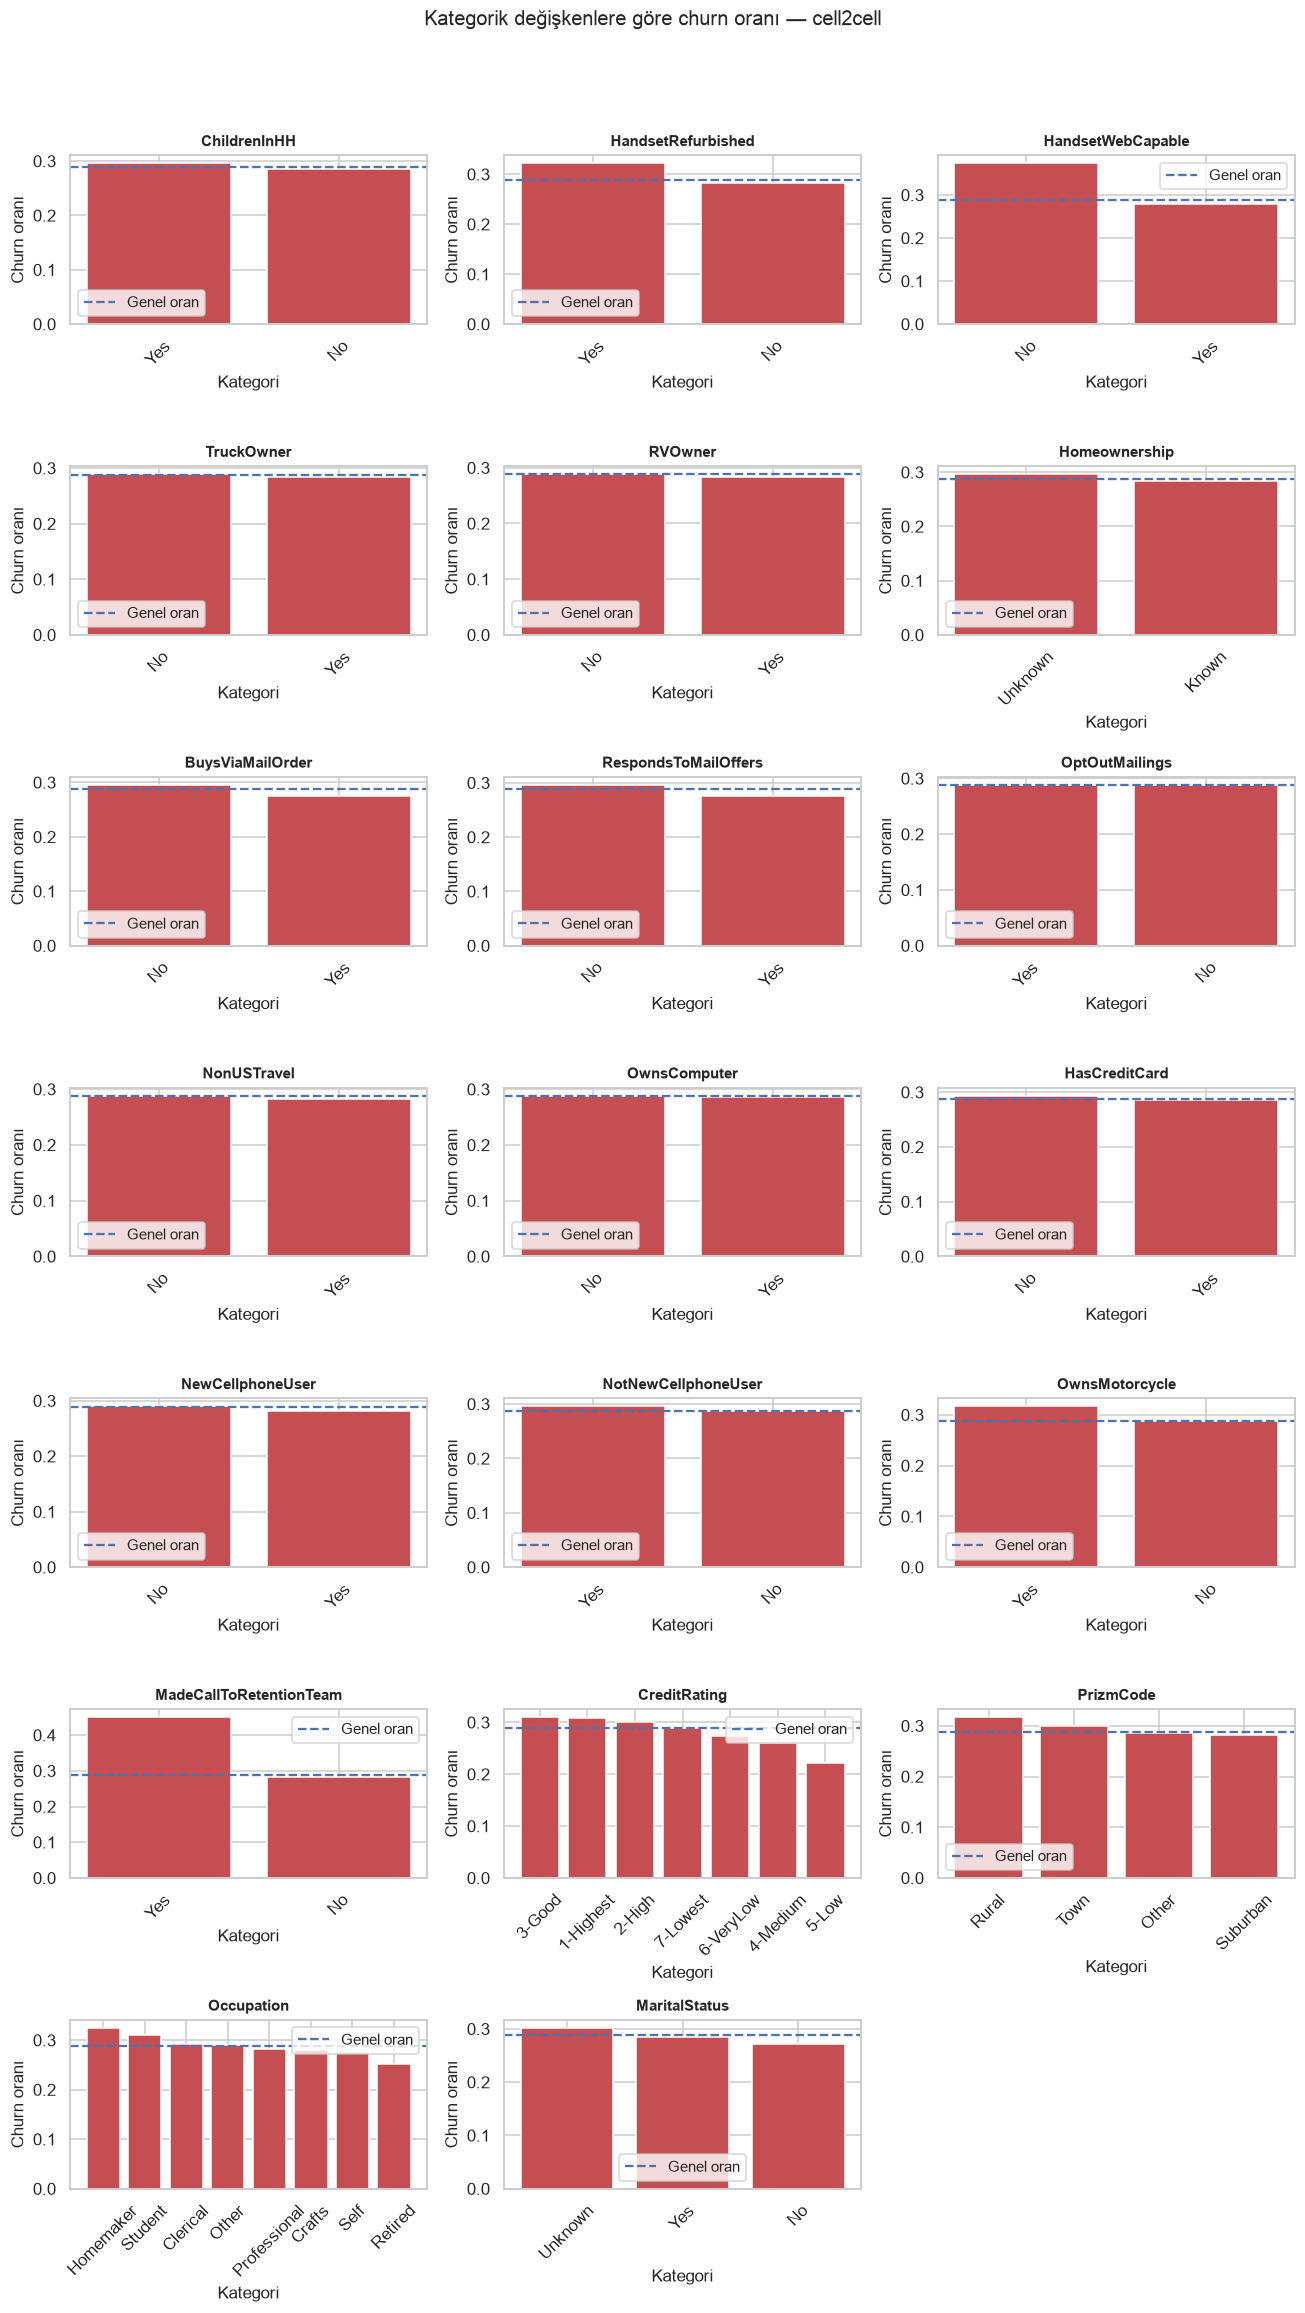

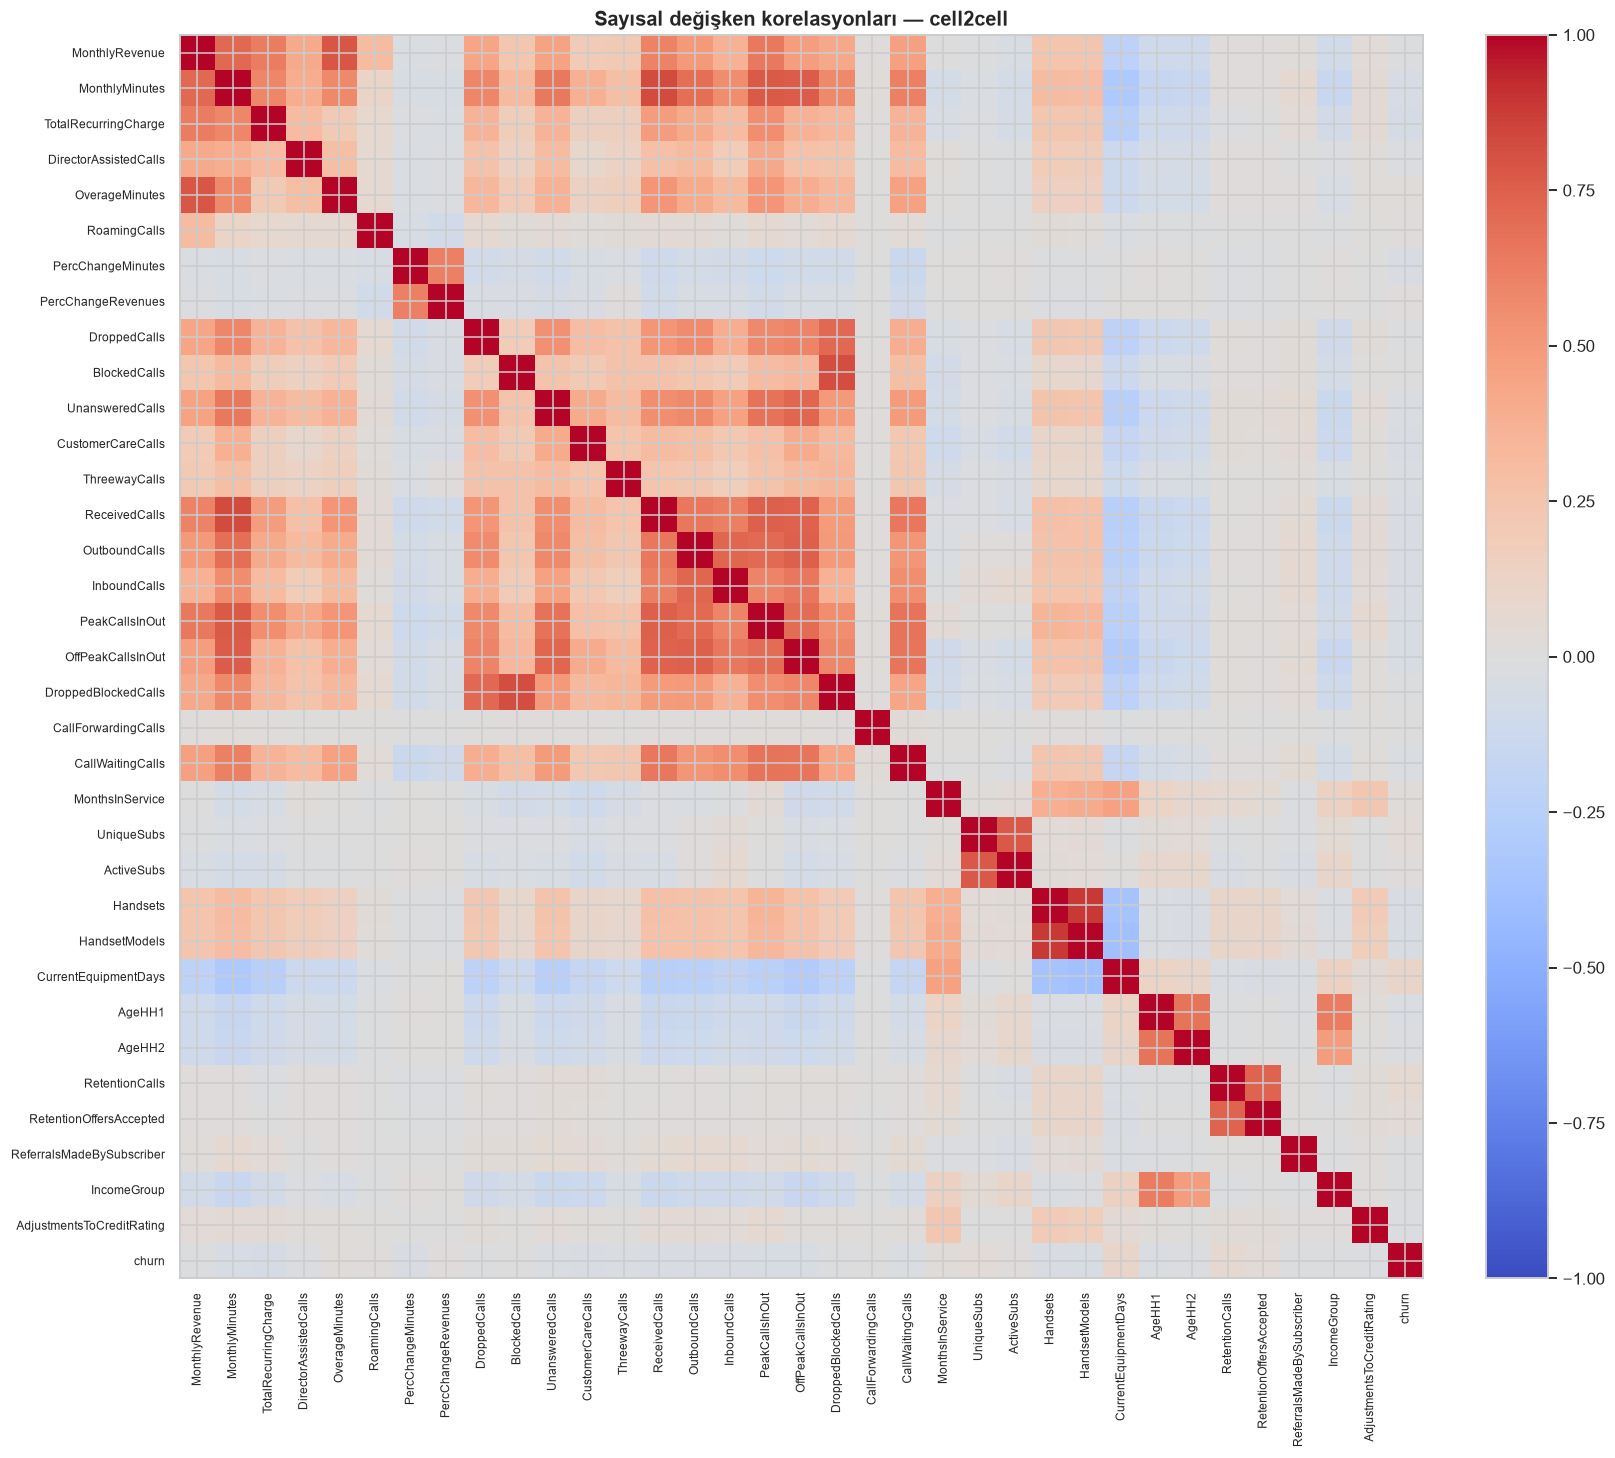

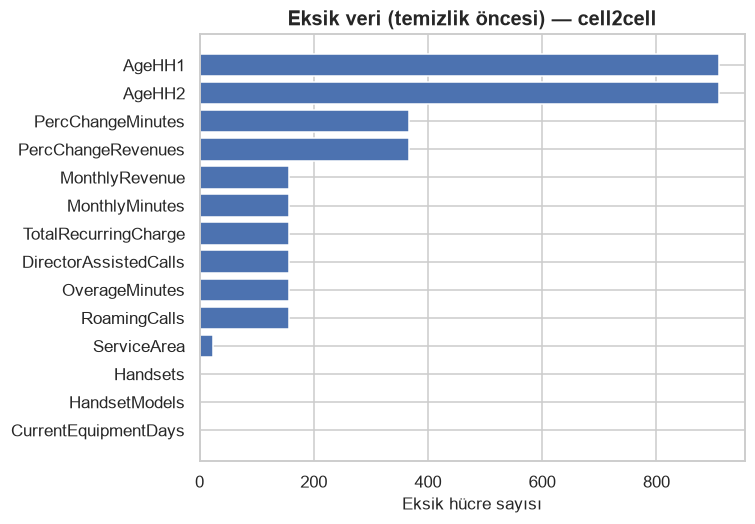

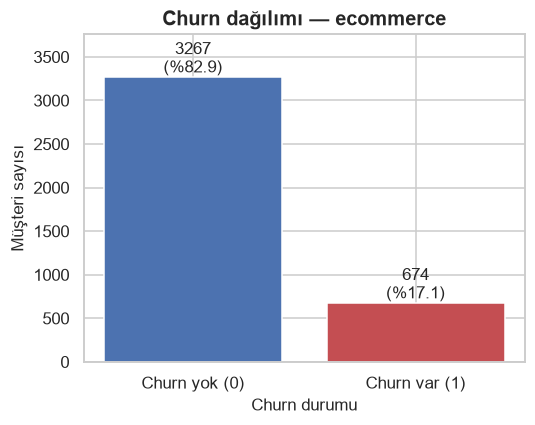

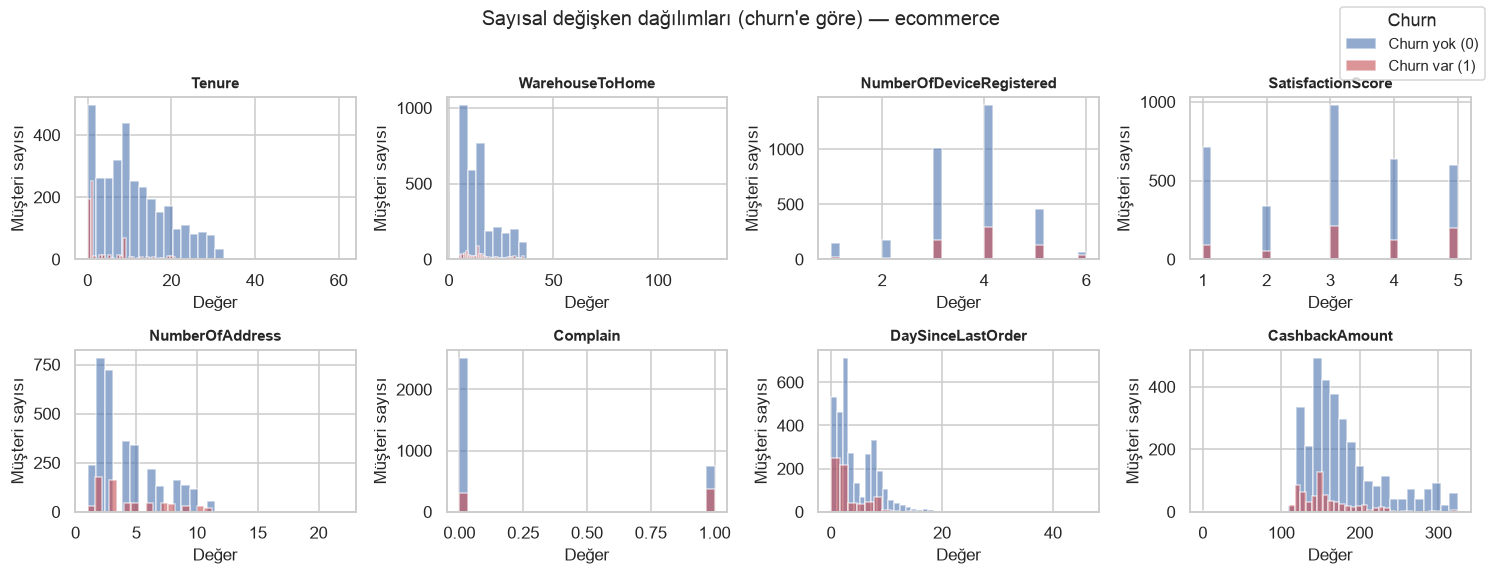

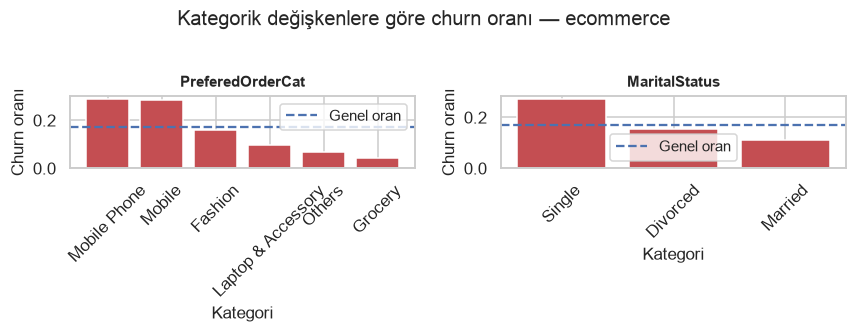

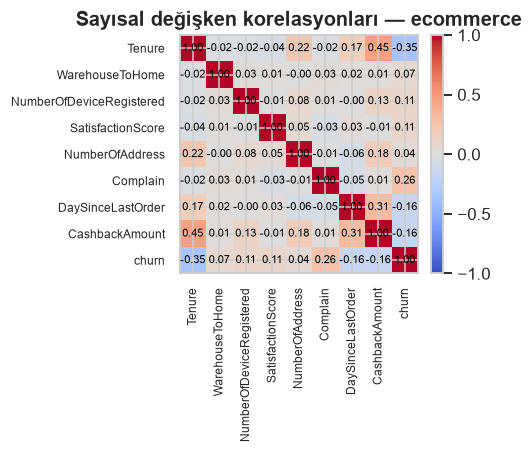

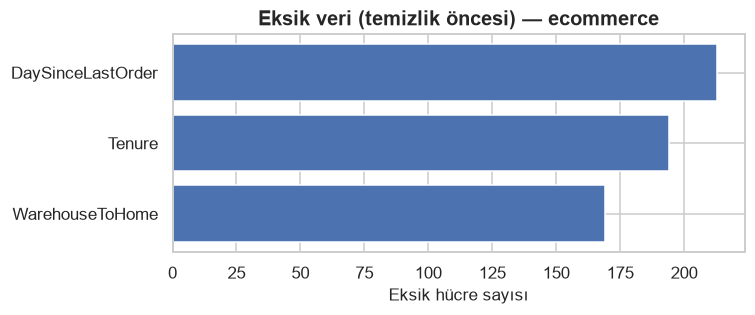

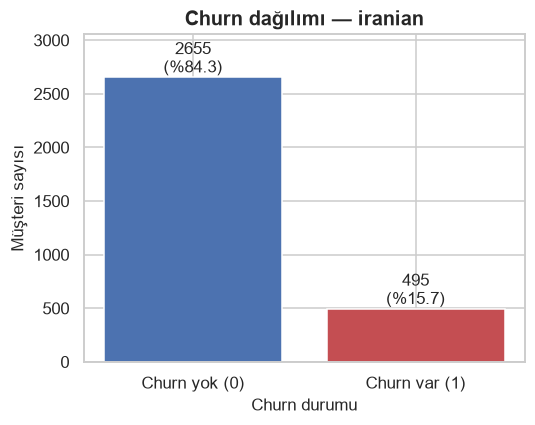

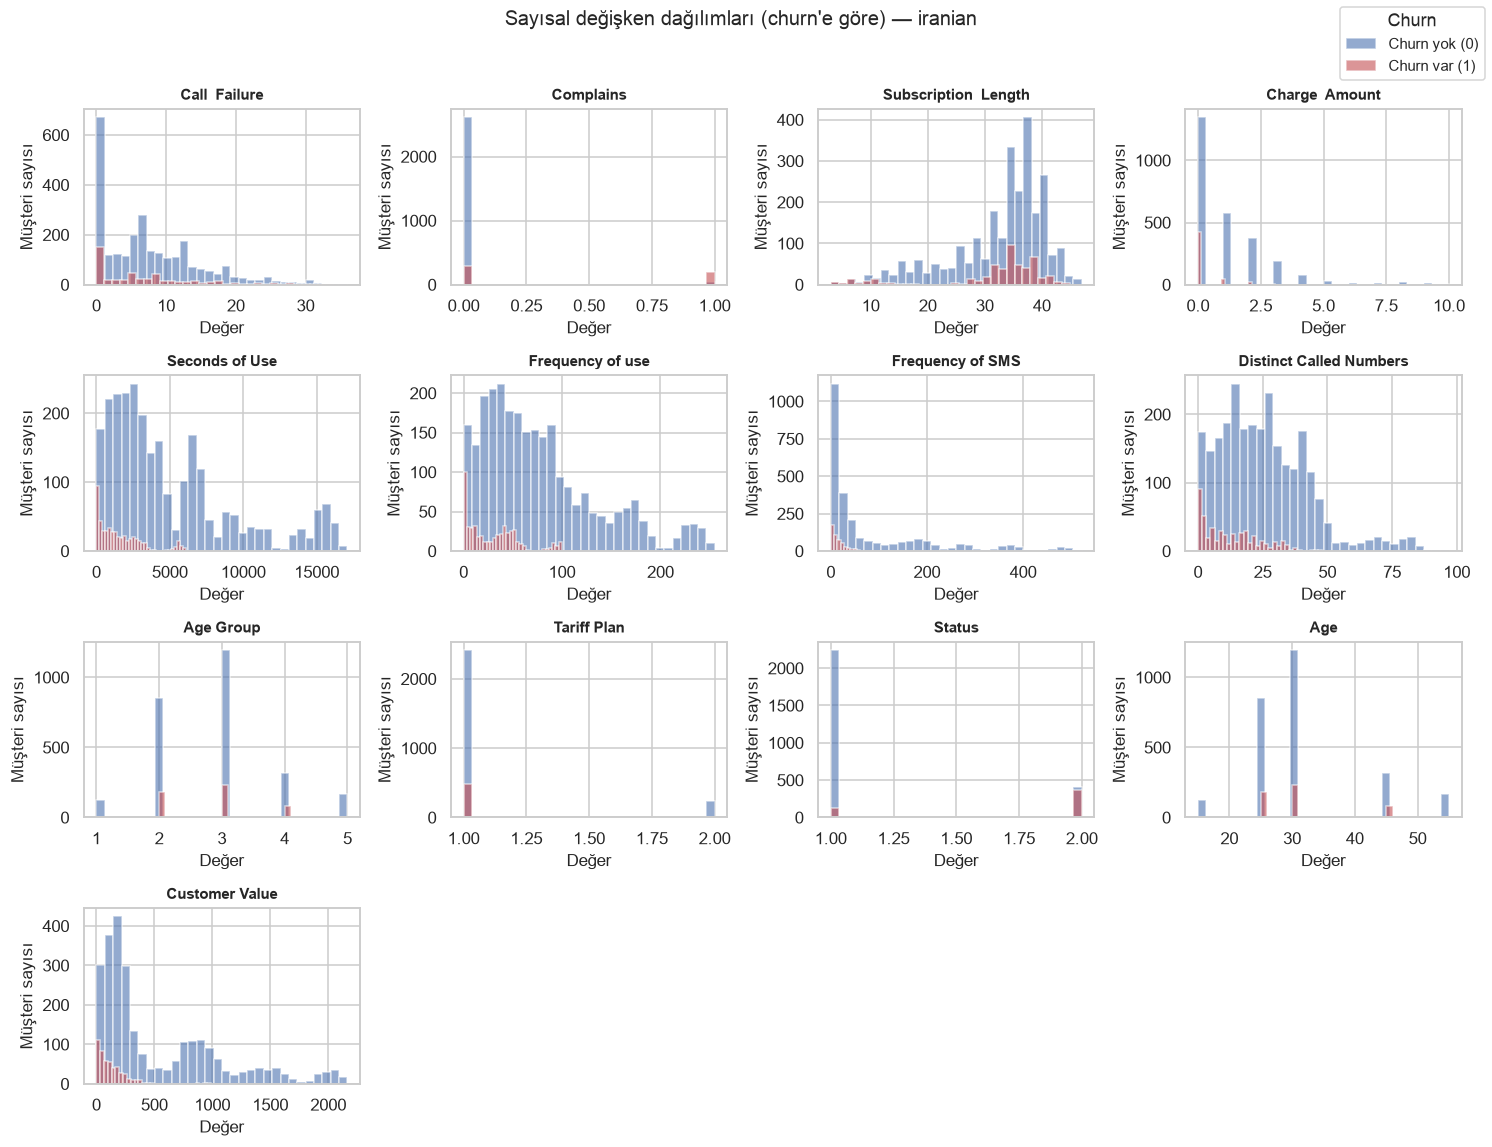

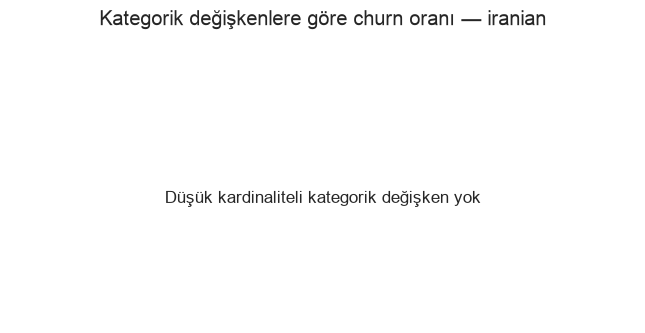

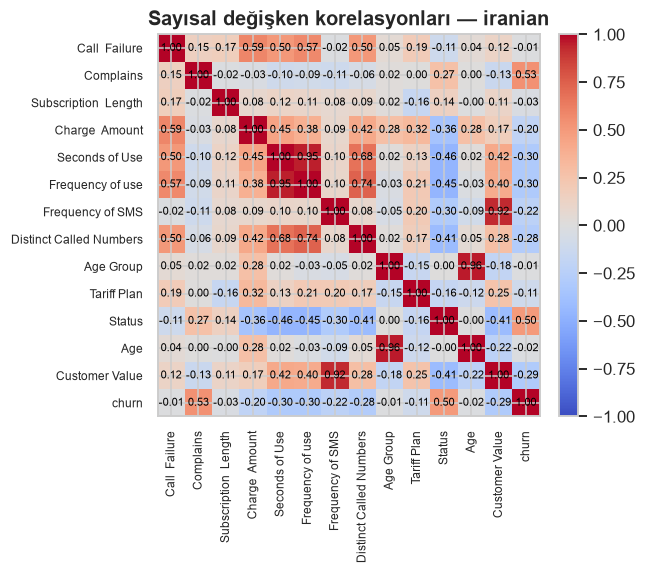

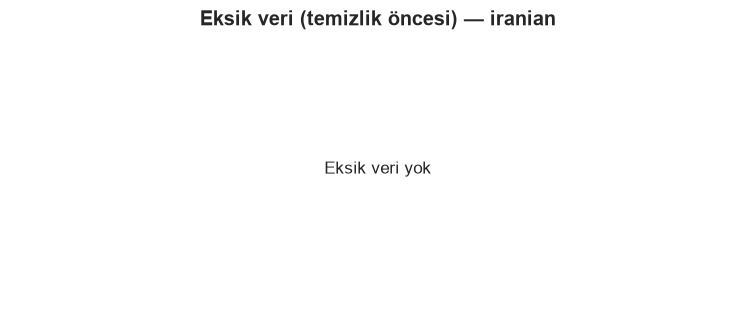

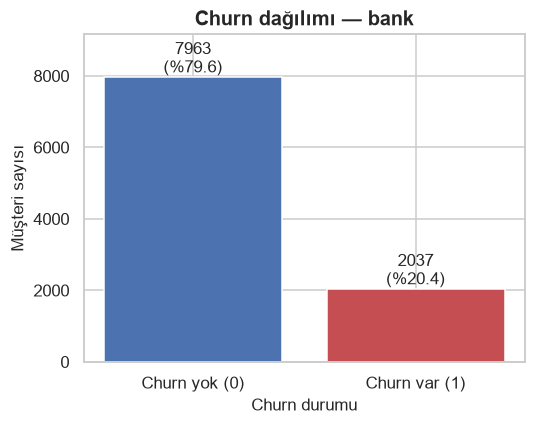

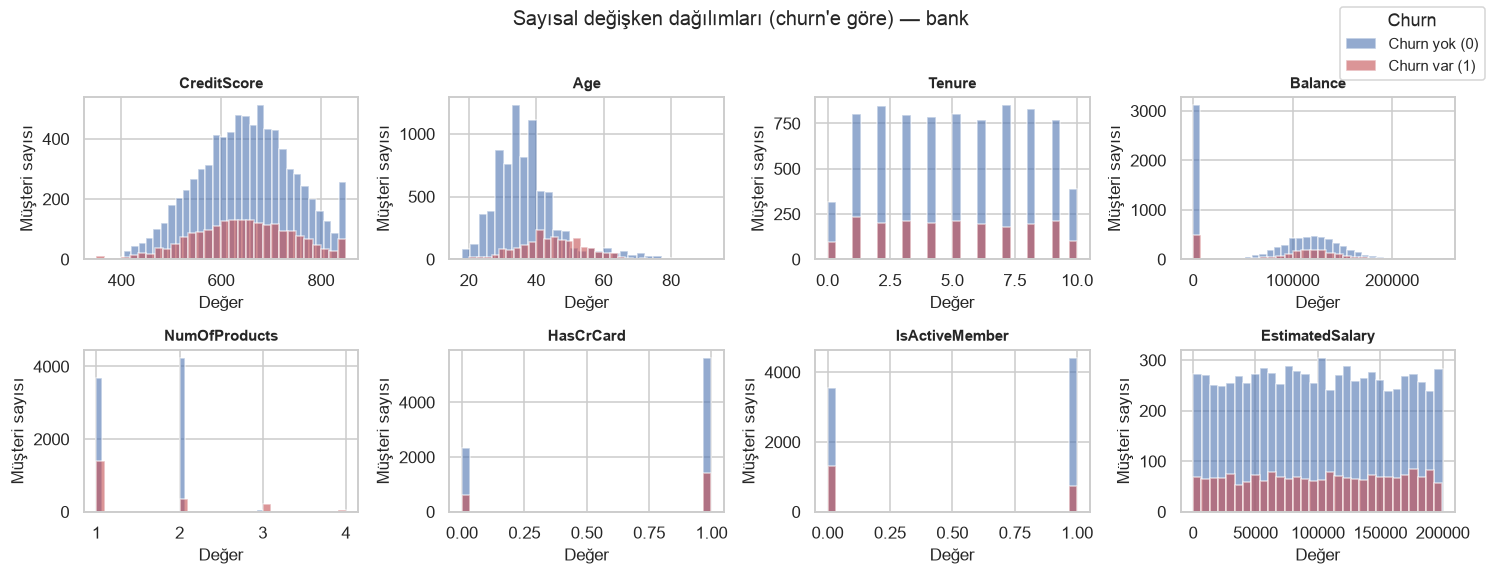

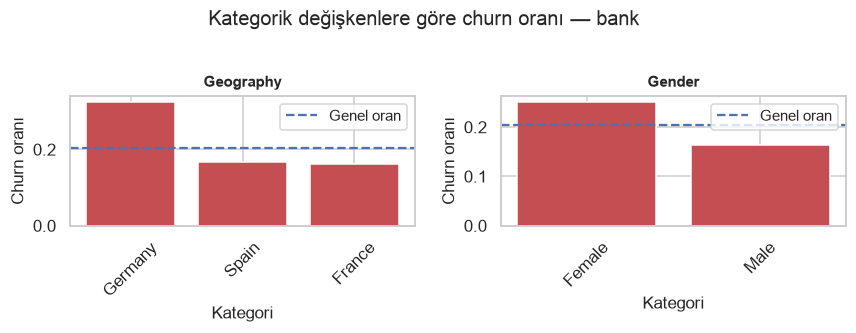

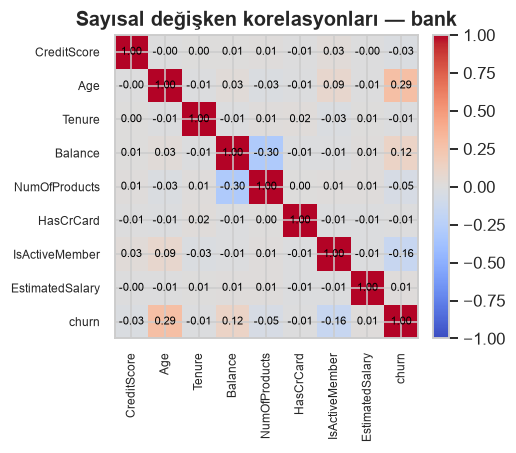

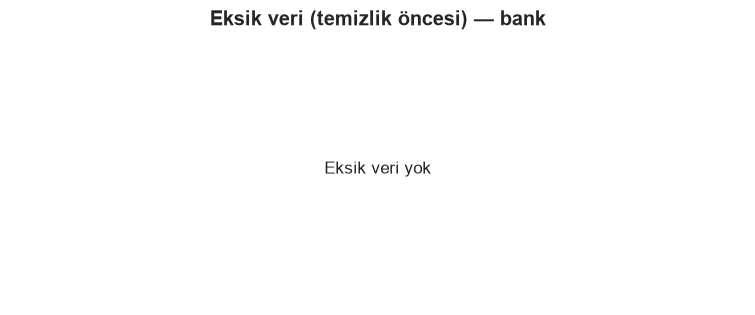

In [5]:
yaz(S.MSG["bolum"].format(ad="EDA FİGÜRLERİ"))
for key in cfg.DATASETS:
    yollar, atlanan = eda_mod.figurler_set(key, processed[key], etiketli[key]["df"])
    yaz(f"{key}: {len(yollar)} figür -> {cfg.FIGURES / key}")
    if atlanan:
        yaz(f"    (yüksek kardinalite, kategorik figürde atlandı: {atlanan})")

overview = eda_mod.genel_bakis(etiketli, processed, holdout)
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "dataset_overview.csv"))
yaz(overview.to_string(index=False))

## 5. Özet
Konsol özeti `outputs/logs/` altına da yazılır. Düşürme kararı (leakage)
kullanıcıya bırakıldı; modellemeye geçilmedi.

In [6]:
yaz(S.MSG["bolum"].format(ad="ÖZET"))
yaz(f"İşlenen etiketli set: {len(cfg.DATASETS)} | etiketsiz holdout: 1")
yaz(f"Temizlik kararı satırı: {len(temizlik_log)} | şüpheli feature: {len(supheli)}")
yaz(S.MSG["bitti"])

_log_yol = cfg.LOGS / "adim1_ozet.log"
_log_yol.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log_yol))

===== ÖZET =====
İşlenen etiketli set: 5 | etiketsiz holdout: 1
Temizlik kararı satırı: 31 | şüpheli feature: 0
ADIM 1 tamamlandı. Düşürme kararı kullanıcıya bırakıldı (leakage). Modellemeye geçilmedi.
Kaydedildi: /Users/emrahfidan/Desktop/churn-xai-profit/outputs/logs/adim1_ozet.log
